In [28]:
from enspara import ra, msm
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# from https://www.statology.org/gini-coefficient-python/
# def gini(x):
#     total = 0
#     for i, xi in enumerate(x[:-1], 1):
#         total += np.sum(np.abs(xi - x[i:]))
#     return total / (len(x)**2 * np.mean(x))

# from SO: https://stackoverflow.com/questions/48999542/more-efficient-weighted-gini-coefficient-in-python
def gini(x, w=None):
    # The rest of the code requires numpy arrays.
    x = np.asarray(x)
    if w is not None:
        w = np.asarray(w)
        sorted_indices = np.argsort(x)
        sorted_x = x[sorted_indices]
        sorted_w = w[sorted_indices]
        # Force float dtype to avoid overflows
        cumw = np.cumsum(sorted_w, dtype=float)
        cumxw = np.cumsum(sorted_x * sorted_w, dtype=float)
        return (np.sum(cumxw[1:] * cumw[:-1] - cumxw[:-1] * cumw[1:]) /
                (cumxw[-1] * cumw[-1]))
    else:
        sorted_x = np.sort(x)
        n = len(x)
        cumx = np.cumsum(sorted_x, dtype=float)
        # The above formula, with all weights equal to 1 simplifies to:
        return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

In [9]:
builder = msm.builders.normalize
its_lags = np.linspace(10,500, 100, dtype=int)
clusp = Path('rmsd-clustering-2025-12-02')
print(its_lags)

[ 10  14  19  24  29  34  39  44  49  54  59  64  69  74  79  84  89  94
  99 104 108 113 118 123 128 133 138 143 148 153 158 163 168 173 178 183
 188 193 198 203 207 212 217 222 227 232 237 242 247 252 257 262 267 272
 277 282 287 292 297 302 306 311 316 321 326 331 336 341 346 351 356 361
 366 371 376 381 386 391 396 401 405 410 415 420 425 430 435 440 445 450
 455 460 465 470 475 480 485 490 495 500]


In [29]:
assigns = ra.load(str(clusp/'UP1-WT-short-rad-0.30/assigns.h5'))
its_models = []
implied_timescales = []
for lag in its_lags:
    m = msm.MSM(lag_time=lag, method=builder)
    m.fit(assigns)
    its_models.append(m)
    implied_timescales.append(
        -lag / np.log(msm.eigenspectrum(m.tprobs_, n_eigs=4)[0][1:4])
    )

    

In [31]:
gini(its_models[0].eq_probs_)

0.4321077904840254

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_64376/2988164916.py:5: SyntaxWarning: invalid escape sequence '\l'
  label='$\lambda_{%s}$' % (i+1))
/tmp/ipykernel_64376/2988164916.py:6: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0,70000])


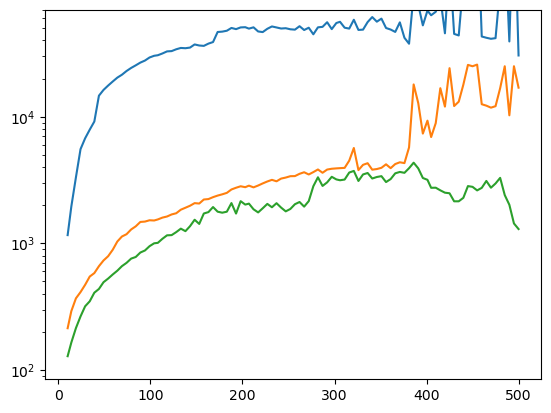

In [12]:
implied_timescales = np.vstack(implied_timescales)
fig, ax = plt.subplots()
for i in range(implied_timescales.shape[1]):
    ax.semilogy(its_lags, implied_timescales[:, i],
             label='$\lambda_{%s}$' % (i+1))
ax.set_ylim([0,70000])
plt.show()

## all clones

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_64376/1457999912.py:27: SyntaxWarning: invalid escape sequence '\l'
  label='$\lambda_{%s}$' % (i+1))


inspecting PCBP1-L100Q-short-rad-0.30


/tmp/ipykernel_64376/1457999912.py:20: RuntimeWarning: divide by zero encountered in divide
  -lag / np.log(msm.eigenspectrum(m.tprobs_, n_eigs=4)[0][1:4])


inspecting PCBP1-wt-short-rad-0.30
inspecting UP1-M72I-short-rad-0.30
inspecting UP1-WT-short-rad-0.30
inspecting hnRNP_A2B1-D76H-rad-0.30
inspecting hnRNP_A2B1-D76N-rad-0.30
inspecting hnRNP_A2B1-D76V-rad-0.30
inspecting hnRNP_A2B1-WT-rad-0.30


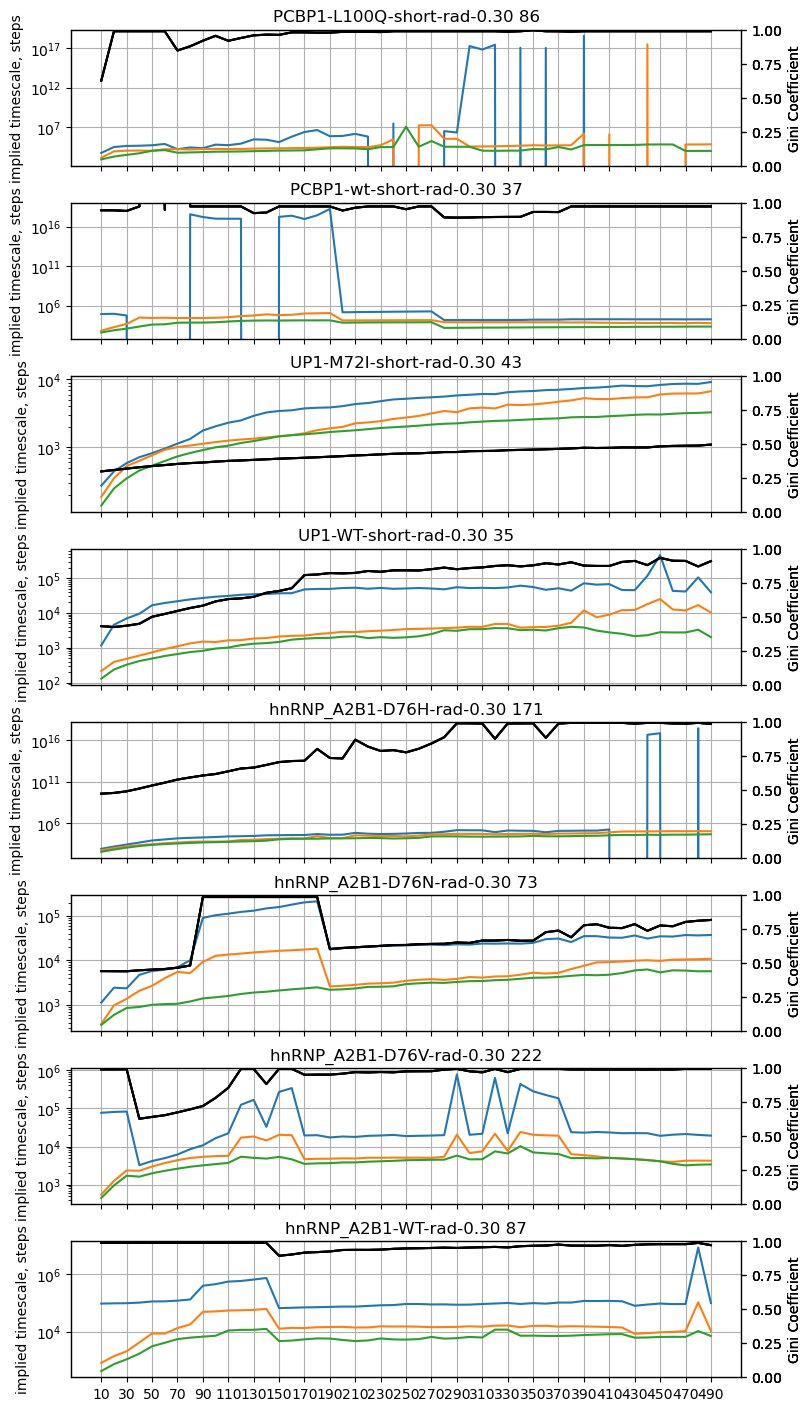

In [39]:
# clusp = Path('rmsd-clustering')
its_lags = np.arange(10,500, 10, dtype=int)
mutants_path_list = [p for p in sorted(clusp.iterdir()) if p.is_dir()]
builder = msm.builders.normalize
fig, axs = plt.subplots(len(mutants_path_list), 1, 
layout='constrained', figsize=(8,14), sharex=True)
for i, mut_cluster in enumerate(mutants_path_list):
    mutn = mut_cluster.name
    print('inspecting',mutn)
    assigns = ra.load(str(mut_cluster/'assigns.h5'))
    bc_assigns = np.bincount(assigns.flatten())
    its_models = []
    implied_timescales = []
    ginis = []
    for lag in its_lags:
        m = msm.MSM(lag_time=lag, method=builder)
        m.fit(assigns)
        its_models.append(m)
        implied_timescales.append(
            -lag / np.log(msm.eigenspectrum(m.tprobs_, n_eigs=4)[0][1:4])
        )
        ginis.append(gini(m.eq_probs_))
    ax = axs.flatten()[i]
    implied_timescales = np.vstack(implied_timescales)
    for i in range(implied_timescales.shape[1]):
        ax.semilogy(its_lags, implied_timescales[:, i],
                label='$\lambda_{%s}$' % (i+1))
        ax.set_ylabel('implied timescale, steps')
        ax.set_xticks(its_lags[::2])
        ax.grid()
        secax = ax.twinx()
        secax.plot(its_lags, ginis, label='gini', color='k')
        secax.set_ylim(0,1)
        secax.set_ylabel('Gini Coefficient')
    # ax.set_ylim([0,40000])
    ax.set_title(f'{mutn} {len(bc_assigns)}')

In [40]:
chosen_lags = {
    'PCBP1-L100Q-short-rad-0.30': 70,
    'PCBP1-wt-short-rad-0.30': 150,
    'UP1-M72I-short-rad-0.30': 160,
    'UP1-WT-short-rad-0.30': 160,
    'hnRNP_A2B1-D76H-rad-0.30': 100,
    'hnRNP_A2B1-D76N-rad-0.30': 80,
    'hnRNP_A2B1-D76V-rad-0.30': 50,
    'hnRNP_A2B1-WT-rad-0.30': 150
}

In [ ]:
model_p = Path('msms')
model_p.mkdir(exist_ok=True)
for clusn, lag in chosen_lags.items(): 
    print('modeling', clusn) usn}/assigns.h5'))
    m = msm.MSM(lag_time=lag, method=builder)
    m.fit(assigns)
    probs = m.eq_probs_
    trans = m.tprobs_
    print('\ttrimming?', m.trim)
    savedir = model_p/clusn
    savedir.mkdir(exist_ok=True)
    np.save(savedir/'eq-probs.npy', probs)
    np.save(savedir/'transition-probs.npy', trans)
    np.save(savedir/'trim.npy', m.trim)
    

modeling PCBP1-L100Q-short-rad-0.30
	trimming? False
modeling PCBP1-wt-short-rad-0.30
	trimming? False
modeling UP1-M72I-short-rad-0.30
	trimming? False
modeling UP1-WT-short-rad-0.30
	trimming? False
modeling hnRNP_A2B1-D76H-rad-0.30
	trimming? False
modeling hnRNP_A2B1-D76N-rad-0.30
	trimming? False
modeling hnRNP_A2B1-D76V-rad-0.30
	trimming? False
modeling hnRNP_A2B1-WT-rad-0.30
	trimming? False
